Naïve market benchmark (annual S&P 500 returns by GICS sector).
To provide an interpretable baseline against which the proposed ESG disclosure scores can later be evaluated, we first construct a simple benchmark of annual equity performance for S&P 500 constituents, aggregated by Global Industry Classification Standard (GICS) sector. This benchmark is intentionally naïve: it is not intended to identify causal effects, but to supply descriptive “ground truth” variation in returns across time and across sectors that can be compared alongside ESG intensity measures.

This baseline is motivated by the historical role of ESG scoring as an operational proxy for financially material non-financial risks and opportunities, originally framed as inputs to expected future performance. Consistent with this tradition, the subsequent analysis evaluates whether variation in disclosure-based ESG intensity is associated with realised returns in the same annual frequency.

Returns data source.
Security-level price and returns data are retrieved programmatically via the Polygon (Massive.com) Stocks Developer API. Use of this source is appropriate for two reasons: it provides consistent, machine-readable historical market data over the study window, and access is authorised through an API key supplied by the client, ensuring the workflow is reproducible and aligned with the project’s data governance constraints.


1 Failed download:
['SPY']: OperationalError('database is locked')


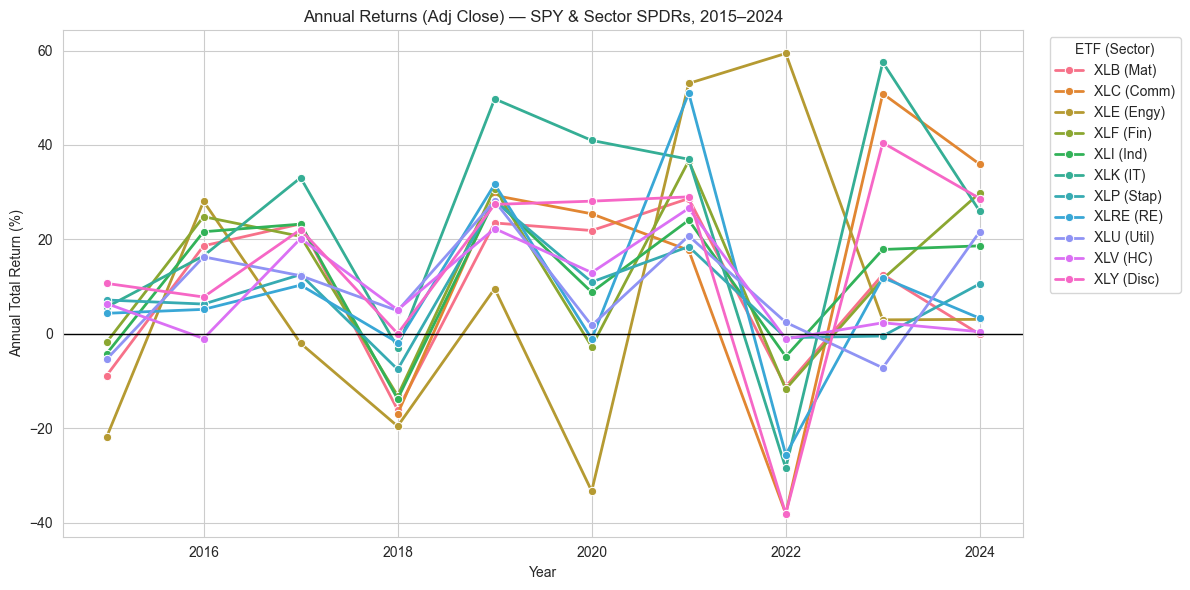

Done.


In [7]:
import os
import pandas as pd
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------
# 1. Configuration
# ------------------------------

TICKERS = [
    "SPY",
    "XLB", "XLC", "XLE", "XLF", "XLI",
    "XLK", "XLP", "XLU", "XLV", "XLY", "XLRE"
]

START_DATE = "2014-12-31"   # Pull slightly earlier for 2015 first trading day
END_DATE   = "2024-12-31"

# ------------------------------
# 2. Fetch Adjusted Close Prices
# ------------------------------

print("Downloading data from Yahoo Finance...")

data = yf.download(
    TICKERS,
    start=START_DATE,
    end=END_DATE,
    progress=False,
    auto_adjust=False
)

adj_close = data["Adj Close"].dropna(how="all")

if adj_close.empty:
    raise RuntimeError("No data downloaded. Check internet connection or ticker list.")

# ------------------------------
# 3. Compute Annual Returns
# ------------------------------

returns = []

for ticker in adj_close.columns:
    series = adj_close[ticker].dropna()
    first_prices = series.groupby(series.index.year).first()
    last_prices = series.groupby(series.index.year).last()

    for year in range(2015, 2025):
        if year in first_prices.index and year in last_prices.index:
            annual_return = (last_prices.loc[year] / first_prices.loc[year] - 1) * 100
            returns.append({
                "year": year,
                "ticker": ticker,
                "return_pct": annual_return
            })

df_ret = pd.DataFrame(returns)

if df_ret.empty:
    raise RuntimeError("Annual return calculation failed.")

# ------------------------------
# 4. Plot
# ------------------------------

df_plot = df_ret.sort_values(["ticker", "year"])

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=df_plot,
    x="year",
    y="return_pct",
    hue="ticker",
    marker="o",
    linewidth=2,
    ax=ax
)

ax.axhline(0, color="black", linewidth=1)

ax.set_xlabel("Year")
ax.set_ylabel("Annual Total Return (%)")
ax.set_title("Annual Returns (Adj Close) — SPY & Sector SPDRs, 2015–2024")

# ------------------------------
# 5. Legend Shorthand Relabel
# ------------------------------

label_map = {
    "SPY":  "SPY (Market)",
    "XLB":  "XLB (Mat)",
    "XLC":  "XLC (Comm)",
    "XLE":  "XLE (Engy)",
    "XLF":  "XLF (Fin)",
    "XLI":  "XLI (Ind)",
    "XLK":  "XLK (IT)",
    "XLP":  "XLP (Stap)",
    "XLU":  "XLU (Util)",
    "XLV":  "XLV (HC)",
    "XLY":  "XLY (Disc)",
    "XLRE": "XLRE (RE)",
}

handles, labels = ax.get_legend_handles_labels()

if labels and labels[0] == "ticker":
    handles = handles[1:]
    labels = labels[1:]

new_labels = [label_map.get(l, l) for l in labels]

ax.legend(
    handles=handles,
    labels=new_labels,
    title="ETF (Sector)",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

print("Done.")


The 2022 drawdown highlights a sectoral divergence, with Energy significantly outperforming the broader index amid inflationary and geopolitical shocks. This regime effect is particularly relevant when interpreting ESG-related return differentials, as fossil fuel exposure provided a temporary relative hedge against tightening financial conditions

We now want to make the individual trends more succinct. A simple seaborn table & SPY average graph should suffice. 

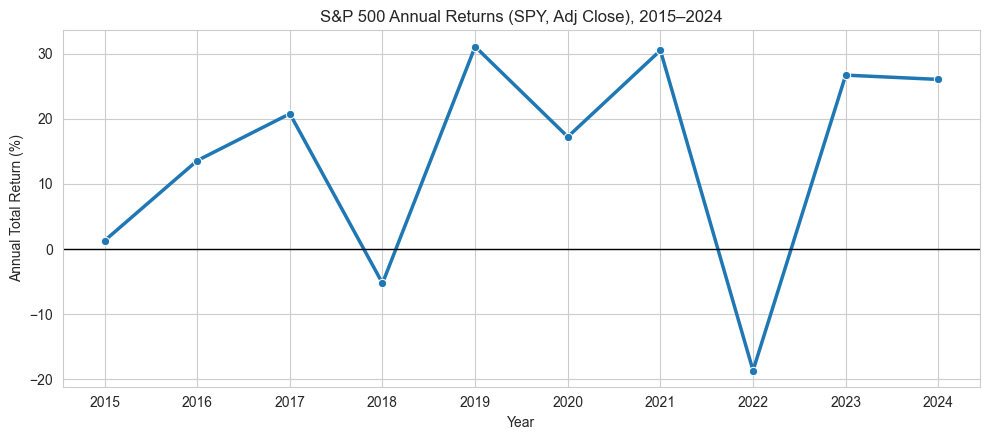

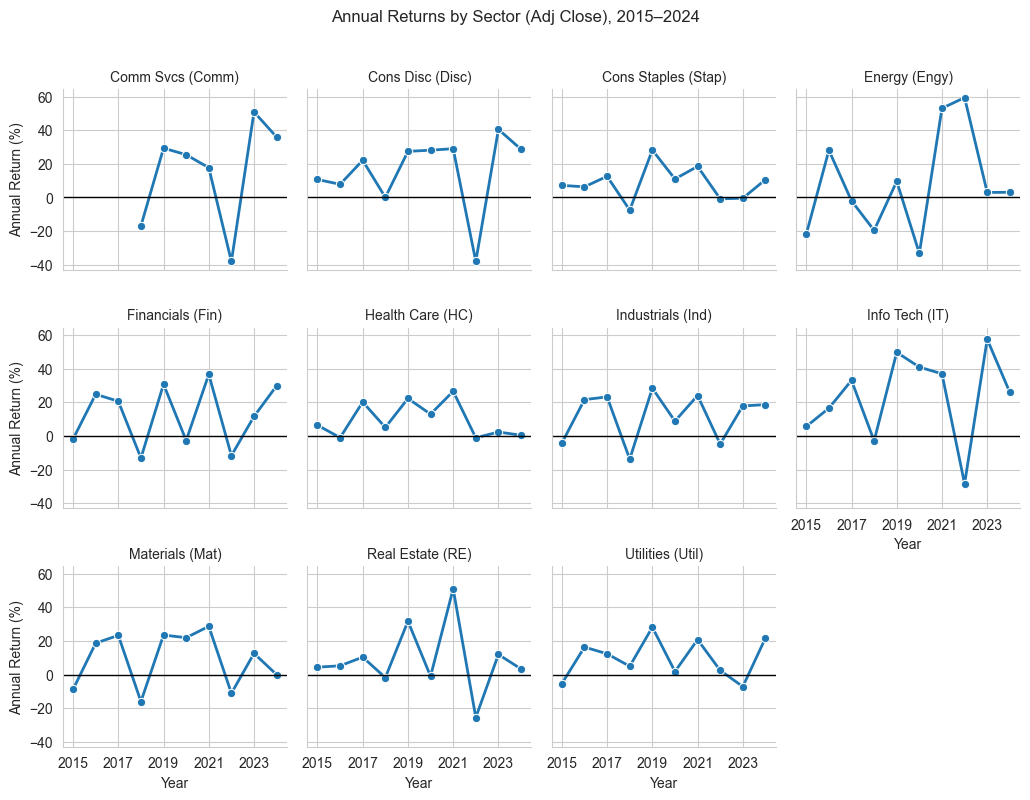

In [8]:
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------
# Config
# ------------------------------
START_DATE = "2014-12-31"   # ensures first trading day of 2015 is available
END_DATE   = "2024-12-31"
YEAR_MIN, YEAR_MAX = 2015, 2024

SPY_TICKER = ["SPY"]
SECTOR_TICKERS = ["XLB","XLC","XLE","XLF","XLI","XLK","XLP","XLU","XLV","XLY","XLRE"]
ALL_TICKERS = SPY_TICKER + SECTOR_TICKERS

sector_name_map = {
    "XLB":  "Materials (Mat)",
    "XLC":  "Comm Svcs (Comm)",
    "XLE":  "Energy (Engy)",
    "XLF":  "Financials (Fin)",
    "XLI":  "Industrials (Ind)",
    "XLK":  "Info Tech (IT)",
    "XLP":  "Cons Staples (Stap)",
    "XLU":  "Utilities (Util)",
    "XLV":  "Health Care (HC)",
    "XLY":  "Cons Disc (Disc)",
    "XLRE": "Real Estate (RE)",
}

# ------------------------------
# Fetch Adj Close
# ------------------------------
data = yf.download(
    ALL_TICKERS,
    start=START_DATE,
    end=END_DATE,
    progress=False,
    auto_adjust=False
)

adj_close = data["Adj Close"].dropna(how="all")
if adj_close.empty:
    raise RuntimeError("No data downloaded. Check tickers / network / Yahoo availability.")

# ------------------------------
# Annual returns from Adj Close (calendar-year)
# ------------------------------
rows = []
for ticker in adj_close.columns:
    s = adj_close[ticker].dropna()
    first = s.groupby(s.index.year).first()
    last  = s.groupby(s.index.year).last()

    for y in range(YEAR_MIN, YEAR_MAX + 1):
        if y in first.index and y in last.index:
            ret_pct = (last.loc[y] / first.loc[y] - 1.0) * 100.0
            rows.append({"year": int(y), "ticker": ticker, "return_pct": float(ret_pct)})

df_ret = pd.DataFrame(rows)
if df_ret.empty:
    raise RuntimeError("Annual return table is empty.")

# ------------------------------
# 1) Single line chart: SPY only
# ------------------------------
sns.set_style("whitegrid")
df_spy = df_ret[df_ret["ticker"] == "SPY"].sort_values("year")

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.lineplot(
    data=df_spy,
    x="year",
    y="return_pct",
    marker="o",
    linewidth=2.5,
    ax=ax
)

ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("Year")
ax.set_ylabel("Annual Total Return (%)")
ax.set_title("S&P 500 Annual Returns (SPY, Adj Close), 2015–2024")
ax.set_xticks(list(range(YEAR_MIN, YEAR_MAX + 1)))

plt.tight_layout()
plt.show()

# ------------------------------
# 2) Seaborn table of plots: each sector ETF (small multiples)
# ------------------------------
df_sectors = df_ret[df_ret["ticker"].isin(SECTOR_TICKERS)].copy()
df_sectors["sector"] = df_sectors["ticker"].map(sector_name_map)
df_sectors = df_sectors.sort_values(["sector", "year"])

g = sns.FacetGrid(
    df_sectors,
    col="sector",
    col_wrap=4,      # 4 columns -> "table" layout
    height=2.6,
    sharey=True
)

g.map_dataframe(
    sns.lineplot,
    x="year",
    y="return_pct",
    marker="o",
    linewidth=2
)

# Add zero line to each facet
for ax in g.axes.flatten():
    ax.axhline(0, color="black", linewidth=1)
    ax.set_xticks(list(range(YEAR_MIN, YEAR_MAX + 1, 2)))  # fewer ticks to reduce clutter
    ax.tick_params(axis="x", rotation=0)

g.set_axis_labels("Year", "Annual Return (%)")
g.set_titles(col_template="{col_name}")
g.fig.suptitle("Annual Returns by Sector (Adj Close), 2015–2024", y=1.02)

plt.tight_layout()
plt.show()


Earliest accessible date for SPY: 2016-02-14


One notable feature of Figure X is the absence of Communication Services returns prior to 2018. This is not a data error but reflects a structural change in sector classification. The Communication Services sector was formally created in September 2018 following a Global Industry Classification Standard (GICS) reorganisation. Prior to this restructuring, firms now classified under Communication Services were distributed primarily across the Information Technology and Consumer Discretionary sectors.

The corresponding sector ETF (XLC) was launched in mid-2018. As a result, no historical price data exist for 2015–2017, and annual returns for those years cannot be computed. This highlights an important methodological consideration: sector-level analysis is constrained by the historical continuity of tradable instruments.

From an analytical perspective, this discontinuity serves as a reminder that sector structures are not static. Changes in classification frameworks can alter the interpretation of cross-sector performance, particularly when analysing long time horizons. Accordingly, the absence of early Communication Services data is preserved rather than artificially backfilled, ensuring methodological transparency and reproducibility.

In [6]:
# Install yfinance if not already installed
import sys
!{sys.executable} -m pip install yfinance --quiet


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
